# Data Organization

This notebook organizes preprocessed images and creates train/validation/test splits.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import shutil
from sklearn.model_selection import train_test_split
from collections import Counter

In [3]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" / "classification"
RESULTS_DIR = PROJECT_ROOT / "results"

In [4]:
df = pd.read_csv(DATA_DIR / "labels_with_class.csv")
print(f"Total samples: {len(df)}")
df.head()

Total samples: 25331


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,class_label
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NV
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,MEL


## 1. Verify Preprocessed Images

Check that all images were successfully preprocessed in notebook 05.

In [5]:
processed_files = list(PROCESSED_DIR.glob("*.jpg"))
processed_names = {f.stem for f in processed_files}
print(f"Preprocessed images found: {len(processed_files)}")

Preprocessed images found: 25331


In [6]:
# Check for missing images
expected_names = set(df["image"].values)
missing = expected_names - processed_names
extra = processed_names - expected_names

print(f"Expected: {len(expected_names)}")
print(f"Missing: {len(missing)}")
print(f"Extra: {len(extra)}")

Expected: 25331
Missing: 0
Extra: 0


In [7]:
# Filter dataframe to only include successfully preprocessed images
df_valid = df[df["image"].isin(processed_names)].copy()
print(f"Valid samples for splitting: {len(df_valid)}")

Valid samples for splitting: 25331


## 2. Class Distribution Analysis

In [8]:
class_counts = df_valid["class_label"].value_counts()
print("Class Distribution:")
print(class_counts)

Class Distribution:
class_label
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64


In [9]:
# Class percentages
class_percentages = (class_counts / len(df_valid) * 100).round(2)
print("\nClass Percentages:")
for cls, pct in class_percentages.items():
    print(f"  {cls}: {pct}%")


Class Percentages:
  NV: 50.83%
  MEL: 17.85%
  BCC: 13.12%
  BKL: 10.36%
  AK: 3.42%
  SCC: 2.48%
  VASC: 1.0%
  DF: 0.94%


In [10]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")


Imbalance ratio (majority/minority): 53.87:1


The extreme imbalance (53.87:1) will require careful handling during training. Stratified splitting ensures each split reflects this distribution.

## 3. Create Stratified Train/Validation/Test Splits

Split ratios: 70% train, 15% validation, 15% test.

Using stratified splitting to maintain class proportions across splits.

In [11]:
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

In [12]:
X = df_valid["image"].values
y = df_valid["class_label"].values

In [13]:
# First split: train vs (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train)}")
print(f"Temp size (val + test): {len(X_temp)}")

Train size: 17731
Temp size (val + test): 7600


In [14]:
# Second split: val vs test (split temp in half)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Validation size: 3800
Test size: 3800


In [15]:
# Verify total
total = len(X_train) + len(X_val) + len(X_test)
print(f"\nTotal: {total} (expected: {len(df_valid)})")
print(f"Actual ratios: {len(X_train)/total:.2%} / {len(X_val)/total:.2%} / {len(X_test)/total:.2%}")


Total: 25331 (expected: 25331)
Actual ratios: 70.00% / 15.00% / 15.00%


## 4. Verify Stratification

In [16]:
def get_class_distribution(labels):
    counts = Counter(labels)
    total = len(labels)
    return {cls: count/total*100 for cls, count in counts.items()}

In [17]:
train_dist = get_class_distribution(y_train)
val_dist = get_class_distribution(y_val)
test_dist = get_class_distribution(y_test)

print("Class distribution comparison (percentages):")
print(f"{'Class':<6} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 32)
for cls in sorted(train_dist.keys()):
    print(f"{cls:<6} {train_dist[cls]:>7.2f}% {val_dist[cls]:>7.2f}% {test_dist[cls]:>7.2f}%")

Class distribution comparison (percentages):
Class     Train      Val     Test
--------------------------------
AK        3.42%    3.42%    3.42%
BCC      13.12%   13.11%   13.13%
BKL      10.36%   10.37%   10.34%
DF        0.94%    0.95%    0.95%
MEL      17.85%   17.84%   17.87%
NV       50.83%   50.84%   50.82%
SCC       2.48%    2.47%    2.47%
VASC      1.00%    1.00%    1.00%


Stratification confirmed - class percentages are consistent across all splits.

## 5. Create Split DataFrames

In [18]:
df_train = pd.DataFrame({"image": X_train, "class_label": y_train, "split": "train"})
df_val = pd.DataFrame({"image": X_val, "class_label": y_val, "split": "val"})
df_test = pd.DataFrame({"image": X_test, "class_label": y_test, "split": "test"})

In [19]:
# Combined dataframe with split labels
df_splits = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"Combined dataframe shape: {df_splits.shape}")

Combined dataframe shape: (25331, 3)


## 6. Save Split Information

In [20]:
# Save to CSV
df_splits.to_csv(DATA_DIR / "splits.csv", index=False)
print("Splits saved to splits.csv")

Splits saved to splits.csv


In [21]:
# Also save individual split files
df_train.to_csv(DATA_DIR / "train_split.csv", index=False)
df_val.to_csv(DATA_DIR / "val_split.csv", index=False)
df_test.to_csv(DATA_DIR / "test_split.csv", index=False)
print("Individual split CSVs saved.")

Individual split CSVs saved.


In [22]:
# Create summary JSON
split_summary = {
    "total_samples": len(df_valid),
    "split_ratios": {
        "train": TRAIN_RATIO,
        "val": VAL_RATIO,
        "test": TEST_RATIO
    },
    "actual_counts": {
        "train": len(X_train),
        "val": len(X_val),
        "test": len(X_test)
    },
    "random_state": RANDOM_STATE,
    "class_counts_per_split": {
        "train": dict(Counter(y_train)),
        "val": dict(Counter(y_val)),
        "test": dict(Counter(y_test))
    },
    "imbalance_ratio": imbalance_ratio
}

In [23]:
with open(DATA_DIR / "split_summary.json", "w") as f:
    json.dump(split_summary, f, indent=2)
    
print("Split summary saved to split_summary.json")

Split summary saved to split_summary.json


## 7. Organize Into Class Folders

Create directory structure for frameworks that expect class-based folder organization.

In [24]:
ORGANIZED_DIR = DATA_DIR / "organized"
CLASS_LABELS = df_valid["class_label"].unique()

In [25]:
def organize_by_class(df_split, split_name, source_dir, target_base_dir):
    """Organize images into class folders for a given split."""
    for class_label in CLASS_LABELS:
        class_dir = target_base_dir / split_name / class_label
        class_dir.mkdir(parents=True, exist_ok=True)
    
    copied = 0
    for _, row in df_split.iterrows():
        src = source_dir / f"{row['image']}.jpg"
        dst = target_base_dir / split_name / row['class_label'] / f"{row['image']}.jpg"
        
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
            copied += 1
    
    return copied

In [26]:
# Organize train set
train_copied = organize_by_class(df_train, "train", PROCESSED_DIR, ORGANIZED_DIR)
print(f"Train: {train_copied} images organized")

Train: 17731 images organized


In [27]:
# Organize validation set
val_copied = organize_by_class(df_val, "val", PROCESSED_DIR, ORGANIZED_DIR)
print(f"Validation: {val_copied} images organized")

Validation: 3800 images organized


In [28]:
# Organize test set
test_copied = organize_by_class(df_test, "test", PROCESSED_DIR, ORGANIZED_DIR)
print(f"Test: {test_copied} images organized")

Test: 3800 images organized


## 8. Verify Directory Structure

In [29]:
def count_images_in_structure(base_dir):
    """Count images in organized directory structure."""
    counts = {}
    for split_dir in base_dir.iterdir():
        if split_dir.is_dir():
            split_name = split_dir.name
            counts[split_name] = {}
            for class_dir in split_dir.iterdir():
                if class_dir.is_dir():
                    class_name = class_dir.name
                    img_count = len(list(class_dir.glob("*.jpg")))
                    counts[split_name][class_name] = img_count
    return counts

In [30]:
structure_counts = count_images_in_structure(ORGANIZED_DIR)

In [31]:
print("Organized Directory Structure:")

for split_name in ["train", "val", "test"]:
    if split_name in structure_counts:
        print(f"\n{split_name.upper()}:")
        split_total = 0
        for class_name in sorted(structure_counts[split_name].keys()):
            count = structure_counts[split_name][class_name]
            split_total += count
            print(f"  {class_name}: {count}")
        print(f"  Total: {split_total}")

Organized Directory Structure:

TRAIN:
  AK: 607
  BCC: 2326
  BKL: 1837
  DF: 167
  MEL: 3165
  NV: 9012
  SCC: 440
  VASC: 177
  Total: 17731

VAL:
  AK: 130
  BCC: 498
  BKL: 394
  DF: 36
  MEL: 678
  NV: 1932
  SCC: 94
  VASC: 38
  Total: 3800

TEST:
  AK: 130
  BCC: 499
  BKL: 393
  DF: 36
  MEL: 679
  NV: 1931
  SCC: 94
  VASC: 38
  Total: 3800


## 9. Summary Visualization

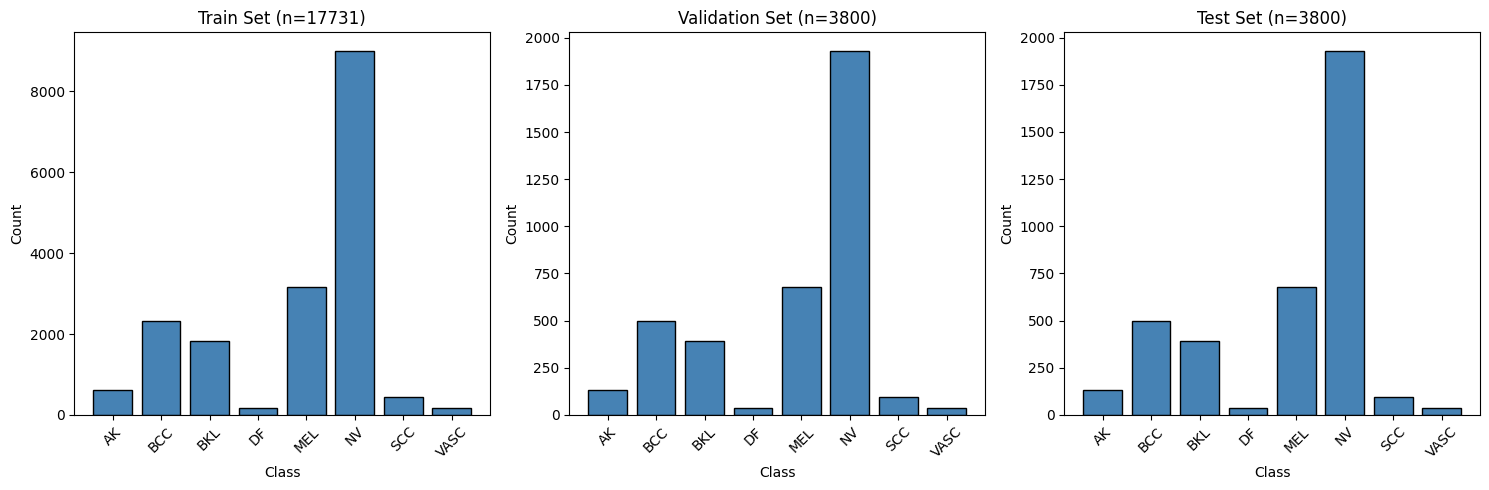

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (split_name, y_split) in enumerate([("Train", y_train), ("Validation", y_val), ("Test", y_test)]):
    counts = Counter(y_split)
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]
    
    axes[idx].bar(classes, values, color="steelblue", edgecolor="black")
    axes[idx].set_title(f"{split_name} Set (n={len(y_split)})")
    axes[idx].set_xlabel("Class")
    axes[idx].set_ylabel("Count")
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "split_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

The stratified splits maintain consistent class distributions across train, validation, and test sets, which is crucial for reliable model evaluation despite the severe class imbalance.

In [33]:
# Final summary
print("Data Organization Complete")
print(f"Train: {len(X_train)} samples")
print(f"Val:   {len(X_val)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"\nFiles saved:")
print(f"  - {DATA_DIR / 'splits.csv'}")
print(f"  - {DATA_DIR / 'split_summary.json'}")
print(f"  - Organized folders in {ORGANIZED_DIR}")

Data Organization Complete
Train: 17731 samples
Val:   3800 samples
Test:  3800 samples

Files saved:
  - data/splits.csv
  - data/split_summary.json
  - Organized folders in data/organized
